In [1]:
!pip install opendatasets

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import opendatasets as od
import tensorflow as tf

In [3]:
od.download("https://www.kaggle.com/datasets/saranpannasuriyaporn/male-female-height-and-weight")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: kethmiisheni
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/saranpannasuriyaporn/male-female-height-and-weight


100%|██████████| 20.3k/20.3k [00:00<00:00, 33.7MB/s]

In [4]:
data = pd.read_csv("/content/male-female-height-and-weight/Test set.csv")

In [5]:
data.head()

,Height,Weight,Sex
0,146.323241,59.861065,Female
1,175.695412,77.863687,Male
2,183.216164,72.131992,Male
3,184.245269,77.546000,Male
4,132.302261,55.188496,Female


In [6]:
# change sex cloumn into numeric value
data['Sex'] = data['Sex'].map({'Male': 1, 'Female': 0})


In [7]:
data.head()


,Height,Weight,Sex
0,146.323241,59.861065,0
1,175.695412,77.863687,1
2,183.216164,72.131992,1
3,184.245269,77.546000,1
4,132.302261,55.188496,0


In [8]:
x = data.drop(['Sex'],axis=1)
y = data['Sex']

In [9]:
x.head()

,Height,Weight
0,146.323241,59.861065
1,175.695412,77.863687
2,183.216164,72.131992
3,184.245269,77.546000
4,132.302261,55.188496


In [10]:
y.head()

,Sex
0,0
1,1
2,1
3,1
4,0


In [11]:
# feature scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
x = pd.DataFrame(x_scaled, columns=['Height', 'Weight'])

In [12]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Height  205 non-null    float64
 1   Weight  205 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [13]:
y[:5]

,Sex
0,0
1,1
2,1
3,1
4,0


In [14]:
y.dtype

dtype('int64')

In [15]:
y = y.astype('int')

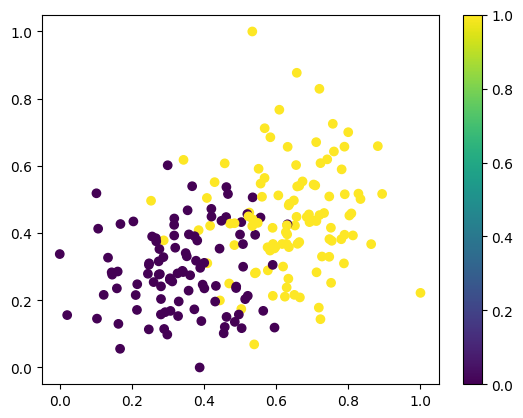

In [16]:
plt.scatter(x['Height'],x['Weight'],c=y)
plt.colorbar()
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [18]:
x_train.shape, x_test.shape

((164, 2), (41, 2))

In [19]:
data.shape

(205, 3)

# model building

In [20]:
# # create model
# model = tf.keras.Sequential([
#     tf.keras.layers.Dense(4, activation= 'relu', input_shape=(2,)),
#     tf.keras.layers.Dense(1, activation= 'sigmoid')
#     ])
# # compile model
# model.compile(loss= tf.keras.losses.BinaryCrossentropy(),
# optimizer= tf.keras.optimizers.Adam(learning_rate = 0.01),
# metrics= ['accuracy'])

# # train model
# model.fit(x_train, y_train, epochs= 5)

# # evaluate model
# model.evaluate(x_test, y_test)

In [21]:
# model.summary()


In [22]:
# y_pred = model.predict(x_test)
# y_pred[:5]

In [23]:
# y_pred[:5]

In [24]:
# y_test[:5]

# OPTION 2

In [25]:
# create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(2, activation='sigmoid')
])

# compile the model
model.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
             optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
             metrics = ["accuracy"])

# train the model
epoch_number = 30
history = model.fit(x_train, y_train, epochs=epoch_number)


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5570 - loss: 0.6726
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7975 - loss: 0.6495 
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6852 - loss: 0.5862 
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7322 - loss: 0.5262 
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8482 - loss: 0.3829 
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8561 - loss: 0.3148 
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8606 - loss: 0.3322 
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8555 - loss: 0.3154 
Epoch 9/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8090 - loss: 0.4127 
Epoch 10/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8475 - loss: 0.3553  
Epoch 11/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8513 - loss: 0.3334 
Epoch 12/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8723 - loss: 0.2945 
Epoch 13/30


In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,144 (113.85 KB)

 Trainable params: 9,714 (37.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,430 (75.90 KB)

# model evaluate

In [27]:
model.evaluate(x_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7807 - loss: 0.3698 


[0.38403943181037903, 0.7804877758026123]

In [28]:
y_pred = model.predict(x_test)
y_pred[:5]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


array([[0.8136831 , 0.34086183],
       [0.50326097, 0.7537645 ],
       [0.4651936 , 0.8131934 ],
       [0.7832479 , 0.33543706],
       [0.55421   , 0.7234738 ]], dtype=float32)

In [29]:
import numpy as np
y_pred = np.argmax(y_pred, axis=1)
y_pred[:5]

array([0, 1, 1, 0, 1])

In [30]:
y_test[:5]

,Sex
15,0
9,1
100,1
132,0
68,1


In [31]:
# precision
precision = tf.keras.metrics.Precision()
precision.update_state(y_test, y_pred)
precision.result()



<tf.Tensor: shape=(), dtype=float32, numpy=0.9230769276618958>

In [32]:
# recall
recall = tf. keras.metrics.Recall()
recall.update_state(y_test, y_pred)
recall.result()

<tf.Tensor: shape=(), dtype=float32, numpy=0.6000000238418579>

<Axes: >

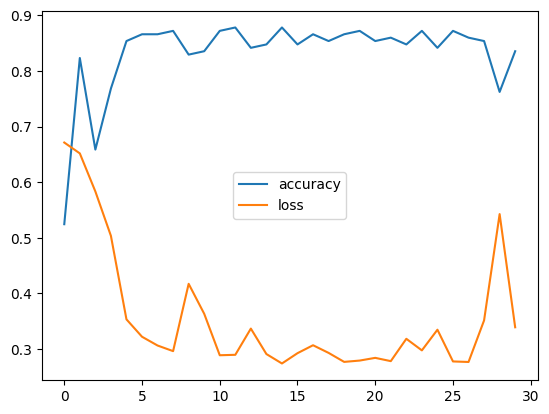

In [33]:
pd.DataFrame(history.history).plot()